In [1]:
import numpy as np
#For reading data from CSV
import pandas as pd
#plotting
import matplotlib.pyplot as plt
import seaborn as sns
#for loading data into pytorch model
from torch.utils.data import TensorDataset, DataLoader
#data preprocessing and splitting
from sklearn.model_selection import train_test_split
#Performance metrics
from sklearn.metrics import confusion_matrix, accuracy_score
#defining model
import torch.nn.functional as F
import torch
from torch import optim
import torch
import torch.nn as nn

# Importing and visualizing dataset

In [2]:
#import the dataset
data_set = pd.read_csv("Iris.csv")
#Let's have a look at the dataset
data_set.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Data Visualization

# Seperating Examples and Labels and string conversion to numerics

In [3]:
Species = {'Iris-setosa': 0,'Iris-versicolor': 1, 'Iris-virginica':2} 
data_set.Species = [Species[item] for item in data_set.Species]
X= data_set.iloc[:, 0:4] #predictors
y= data_set.iloc[:, 4]
from sklearn.preprocessing import normalize
X = normalize(X)
y = np.array(y)
y = y.astype(int)

X_train,X_test,Y_train,Y_test= train_test_split(X, y, test_size= 0.10, random_state= 1)
print ('X_train shape: ',X_train.shape)
print ('y_train shape: ',Y_train.shape)
print ('X_test shape: ',X_test.shape)
print ('y_test shape: ',Y_test.shape)

X_train shape:  (135, 4)
y_train shape:  (135,)
X_test shape:  (15, 4)
y_test shape:  (15,)


## Using Dataloader to convert numpy arrays to Tensors 

In [4]:
#for loading data into pytorch model
from torch.utils.data import TensorDataset, DataLoader
##It represents a Python iterable over a dataset

In [5]:

trainloader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train)),
                         batch_size=135, shuffle=True)
testloader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test)),
                         batch_size=135, shuffle=False)

dataloaders = {
    "train": trainloader,
    "validation": testloader
}

## This class will define our model
### Using __init__ we will define numbers of nodes in our particular layer
### Using forward() we will define functionality of each layer

In [6]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 227) ##4 predictors
        self.fc2 = nn.Linear(227, 94) ##227neuron in hidden layer 1, 94 in 2
        self.fc3 = nn.Linear(94, 75) ##75 neurons in hidden layer 3
        self.fc4 = nn.Linear(75, 3) ##3 classes
        
        self.dropout = nn.Dropout(p=0.2)
        
    def forward(self, x):
        #x = x.view(x.shape[0], -1)
        #print(x)
        
        x = F.relu(self.fc1(x)) ##activation function for 1
        x = F.relu(self.fc2(x))
        x = self.dropout(F.relu(self.fc3(x)))
        x = F.log_softmax(self.fc4(x), dim=1)
        #x = F.log_softmax(self.fc4(x))
        return x

## Model declaration, Type of loss and optimizer.
### We are using adam optimizer to optimize our network

In [7]:
model = Classifier()
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

## This block is showing summary off our model

In [8]:
model

Classifier(
  (fc1): Linear(in_features=4, out_features=227, bias=True)
  (fc2): Linear(in_features=227, out_features=94, bias=True)
  (fc3): Linear(in_features=94, out_features=75, bias=True)
  (fc4): Linear(in_features=75, out_features=3, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

## This function is predicting output of examples we will feed in.
### Will be useful in  calculating model accuracies.

In [9]:
def predict(model, inputs):
    output = model(inputs)
    return output.data.numpy().argmax(axis= 1)

# Here we will perform forward and backward propagation.

In [10]:
from torch.autograd import Variable

loss1=[]
train_acc=[]

Epoch=2000

for epoch in range(Epoch):
    acc=0
    
    for i, (features, labels) in enumerate(trainloader):

        features = Variable(features)

        labels = Variable(labels)

        
## Forward pass and backward pass will happen in these lines of codes----------------------------
        optimizer.zero_grad()

        features=features.float()

        outputs = model(features)

        

        loss = criterion(outputs, labels.long())

        loss.backward() ##backward 

        optimizer.step()
        
#=================================================================================================#  

        

        if (i+1) % len(trainloader) == 0:
            Ypred = predict(model, torch.from_numpy(X_train).float())
            acc = np.mean(Y_train == Ypred)
#             train_acc1=train_accuracy/len(trainloader)

            train_acc1=acc/len(trainloader)
            train_acc.append(train_acc1)
            loss1.append(loss.data)

            print ('Epoch [%d/%d], Iter [%d] Loss: %.4f Training Accuracy: %.5f' %(epoch+1, 2000, i+1, loss.data, train_acc1 ))


Epoch [1/2000], Iter [1] Loss: 1.1263 Training Accuracy: 0.18519
Epoch [2/2000], Iter [1] Loss: 1.1206 Training Accuracy: 0.18519
Epoch [3/2000], Iter [1] Loss: 1.1192 Training Accuracy: 0.18519
Epoch [4/2000], Iter [1] Loss: 1.1182 Training Accuracy: 0.18519
Epoch [5/2000], Iter [1] Loss: 1.1203 Training Accuracy: 0.18519
Epoch [6/2000], Iter [1] Loss: 1.1176 Training Accuracy: 0.18519
Epoch [7/2000], Iter [1] Loss: 1.1149 Training Accuracy: 0.18519
Epoch [8/2000], Iter [1] Loss: 1.1137 Training Accuracy: 0.18519
Epoch [9/2000], Iter [1] Loss: 1.1158 Training Accuracy: 0.18519
Epoch [10/2000], Iter [1] Loss: 1.1129 Training Accuracy: 0.18519
Epoch [11/2000], Iter [1] Loss: 1.1077 Training Accuracy: 0.18519
Epoch [12/2000], Iter [1] Loss: 1.1121 Training Accuracy: 0.17778
Epoch [13/2000], Iter [1] Loss: 1.1089 Training Accuracy: 0.17778
Epoch [14/2000], Iter [1] Loss: 1.1073 Training Accuracy: 0.17778
Epoch [15/2000], Iter [1] Loss: 1.1052 Training Accuracy: 0.19259
Epoch [16/2000], It

## we will plot our accuracies and loss functions below. 

In [11]:
np_loss=loss1[0].numpy()
for i in range(len(loss1)):
    np_loss=np.append(np_loss, loss1[i])

np_acc=train_acc[0]
for i in range(len(train_acc)):
    np_acc=np.append(np_acc, train_acc[i])
    

# Training Accuracy
    

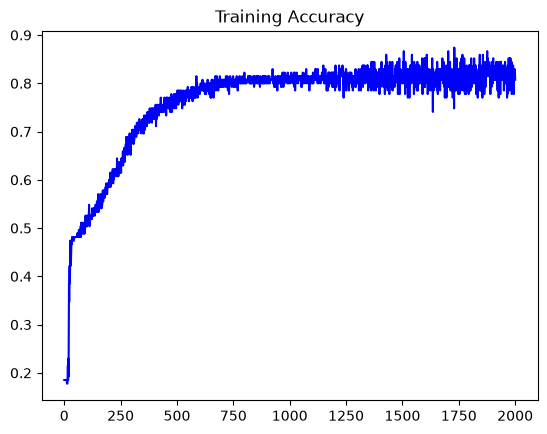

In [12]:
%matplotlib inline
plt.plot(np_acc, color='blue')
plt.title("Training Accuracy")
plt.show()

# Training Loss

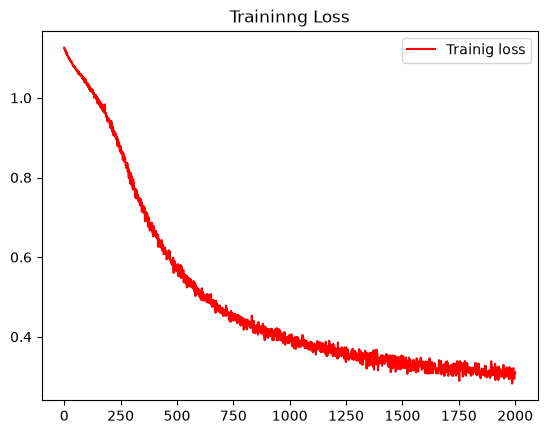

In [13]:
%matplotlib inline
plt.plot(np_loss, color='red', label='Trainig loss')
plt.title("Traininng Loss")
plt.legend()
plt.show()

# Training loss and accuracy curves

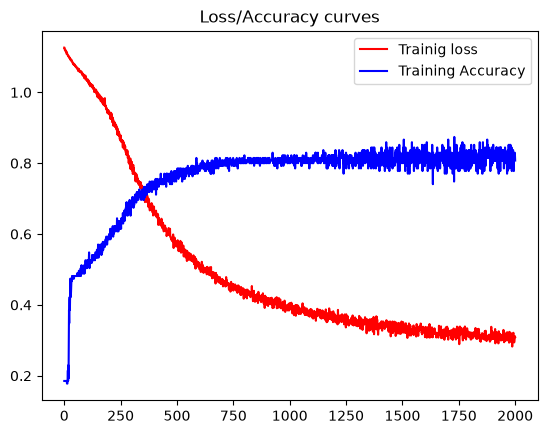

In [14]:
%matplotlib inline
plt.plot(np_loss, color='red', label='Trainig loss')
plt.plot(np_acc, color='blue', label='Training Accuracy')
plt.title("Loss/Accuracy curves")
plt.legend()
plt.show()

# Test Accuracy 

In [15]:
Ypred = predict(model, torch.from_numpy(X_test).float())
acc = np.mean(Y_test == Ypred)
print('Test accuracy: ', acc)

Test accuracy:  0.7333333333333333


# Precision, Recall, F1 Score

In [16]:
from sklearn.metrics import classification_report
target_names = ['data_set-setosa', 'data_set-versicolor', 'data_set-virginica']
print(classification_report(Y_test, Ypred, target_names=target_names))

                     precision    recall  f1-score   support

    data_set-setosa       1.00      1.00      1.00         5
data_set-versicolor       0.60      1.00      0.75         6
 data_set-virginica       0.00      0.00      0.00         4

           accuracy                           0.73        15
          macro avg       0.53      0.67      0.58        15
       weighted avg       0.57      0.73      0.63        15



/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par